<a href="https://colab.research.google.com/github/rebeccavanni/demo/blob/main/HW5_linechart_BLANK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW5: Creating Charts that Show Time
Course: DS2023

**Rebecca Vanni**

**Topic:** Data Visualization           
**Purpose:** To practice graphing time.        
**Instructions:** Create a graph using the data provided and prompts below.       
Please comment your code to document your understanding. A code chunk follows each problem. You can use as many code chunks as you need to show your work.         
**Submission:** Upload an html to Canvas.       
**Learning Objective:** Students will be able to construct basic visualizations (e.g., bar charts, scatter plots, line graphs) and customize elements such as labels, colors, and scales to improve interpretability.      

*15 points*

### Set-up your environment

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

### Create a Graph
* In the data folder, attached to this assignment, you will find a file called `uva_stats_DS2023.csv`. This file contains games stats data of the current UVA MBB team for the 24-25 season. Variables include:     
  * `PLAYER`: player name   
  * `GAMEDATE`: date of the game    
  * `OPPONENT`: name of the opponent    
  * `POINTS`: points scored by the player during the game - points are scored by making field goals (2 or 3 pointers) or free throws    
  * `REBOUNDS`: rebounds by the player during the game - rebounds are when a player retrieves the ball after a missed field goal or free throw  
  * `ASSISTS`: assists by the player during the game - assists are passes that directly lead to a basket    

* Note: The data source is ESPN.

* Create a graph that shows time. You can decided which players, stats, and time frame to use.  
  * This is intentionally vague. I want you to read about the team, explore the data, and create a graph that tells a story.    
* Remember to use the concepts we have learned in class to make your graph is **clear, visually appealing and informative**.  

Rubric:
You will be graded on the following:
* 5 points: student loads the data and creates a graph
* 10 points: student generally applies concepts learned in class to make the graph clear, visually appealing and informative.
* 15 points: student creates an exceptional graph that tells a compelling story.

In [3]:
df = pd.read_csv("/content/uva_stats_DS2023(in).csv")
df.head(15)

,PLAYER,GAMEDATE,OPPONENT,POINTS,REBOUNDS,ASSISTS
0,Andrew Rohde,11/6/2024,Campbell Fighting Camels,1,3,5
1,Blake Buchanan,11/6/2024,Campbell Fighting Camels,10,7,5
2,Dai Dai Ames,11/6/2024,Campbell Fighting Camels,2,2,1
3,Elijah Saunders,11/6/2024,Campbell Fighting Camels,11,5,0
4,Isaac McKneely,11/6/2024,Campbell Fighting Camels,11,2,2
5,Ishan Sharma,11/6/2024,Campbell Fighting Camels,6,3,2
6,Jacob Cofie,11/6/2024,Campbell Fighting Camels,16,6,1
7,TJ Power,11/6/2024,Campbell Fighting Camels,3,3,1
8,Taine Murray,11/6/2024,Campbell Fighting Camels,5,1,0
9,Anthony Robinson,11/11/2024,Coppin State Eagles,2,2,0


In [ ]:
#seperating the data that will be used in the graph (comparing their points)
rodhe_data = df[(df['PLAYER'] == 'Andrew Rohde')]

In [8]:
#to put line at the mean amount of points scored per player
mean = df['POINTS'].mean()

6.47906976744186


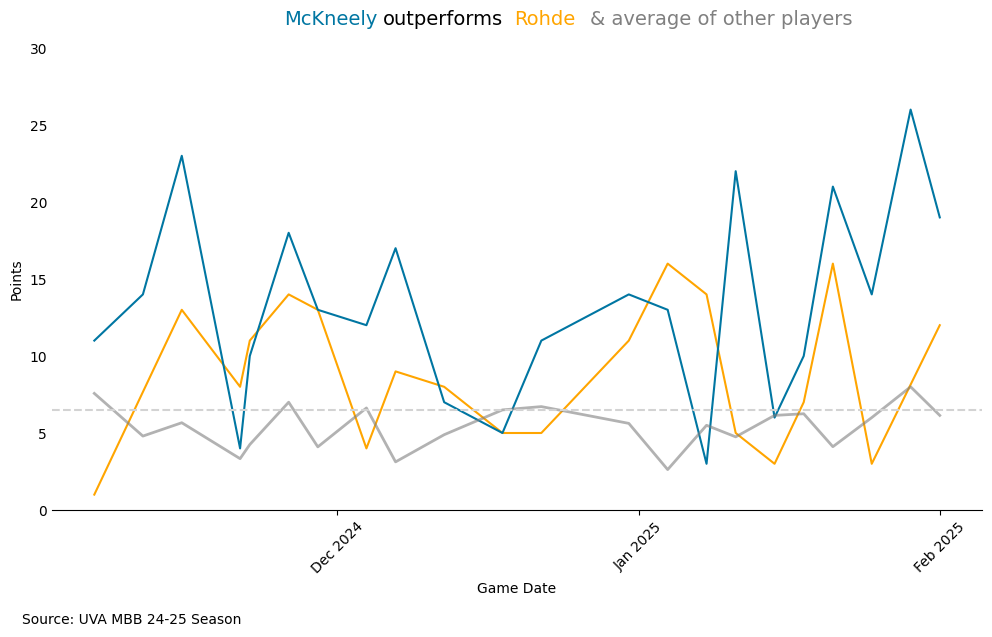

In [34]:
df['GAMEDATE'] = pd.to_datetime(df['GAMEDATE'])
df = df.sort_values(by='GAMEDATE')

plt.figure(figsize=(12, 6))

for PLAYER in df['PLAYER'].unique():
    player_data = df[df['PLAYER'] == PLAYER]  # Filter by player

    if PLAYER == 'Isaac McKneely':
        plt.plot(player_data['GAMEDATE'], player_data['POINTS'], linestyle='-', color='#0076a2', label='Isaac McKneely')
    elif PLAYER == 'Andrew Rohde':
        rohde_data = df[df['PLAYER'] == 'Andrew Rohde']
        plt.plot(rohde_data['GAMEDATE'], rohde_data['POINTS'], linestyle='-', color='orange', label='Andrew Rohde')
#other players
other_players_df = df[~df['PLAYER'].isin(['Isaac McKneely', 'Andrew Rohde'])]  # Exclude McKneely & Rohde
avg_points_per_game = other_players_df.groupby('GAMEDATE')['POINTS'].mean().reset_index()
plt.plot(avg_points_per_game['GAMEDATE'], avg_points_per_game['POINTS'], linestyle='-', color='gray', label='Avg Other Players', linewidth=2, alpha=0.6)


# Add title and labels
plt.text(0.3, 1.05,
         "McKneely", fontsize=14, color='#0076a2', ha='center', transform=plt.gca().transAxes)
plt.text(0.42, 1.05,
         "outperforms", fontsize=14, color='black', ha='center', transform=plt.gca().transAxes)
plt.text(0.53, 1.05,
         "Rohde", fontsize=14, color='orange', ha='center', transform=plt.gca().transAxes)
plt.text(0.72, 1.05,
         "& average of other players", fontsize=14, color='gray', ha='center', transform=plt.gca().transAxes)


plt.xlabel("Game Date")
plt.ylabel("Points")

# Set y-axis limits and ticks
plt.ylim(0,30)
plt.yticks(np.arange(0, 31, 5))
plt.tick_params(axis='y', which='both', length=0)  # Remove y-axis ticks

# Format x-axis to show one tick per month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # One tick per month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))  # Format as 'Jan 2024'

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Remove gridlines
plt.grid(False)

# Add a light gray horizontal line at y=15
plt.axhline(y=mean, color='lightgray', linestyle='--')

# Add a caption
plt.figtext(0.1, -0.08, 'Source: UVA MBB 24-25 Season', ha='left', fontsize=10)

# Remove unnecessary spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)


# Display the plot
plt.show()